# 05 — Epoch Folding

This notebook builds a folded pulse profile using the detected pulsation period of the Vela pulsar.

## Objectives

- load the preprocessed photon event dataset;
- fold photon arrival times by the detected period;
- build a phase histogram;
- visualize the folded pulse profile;
- save the pulse profile plot.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path.cwd().parent

processed_path = PROJECT_ROOT / "data" / "processed" / "vela_photons_filtered.csv"
images_dir = PROJECT_ROOT / "notebooks" / "images"

images_dir.mkdir(parents=True, exist_ok=True)

processed_path

WindowsPath('C:/Users/vi/pulsar-clean/data/processed/vela_photons_filtered.csv')

In [3]:
df_filtered = pd.read_csv(processed_path)

df_filtered.head()

,time,energy,time_rel
0,7.805337e+08,326.514008,79221.431558
1,7.805415e+08,207.780685,87021.198388
2,7.805529e+08,229.124054,98457.021602
3,7.805640e+08,271.309235,109584.648355
4,7.806201e+08,207.057602,165607.811719


In [4]:
df_filtered.info()

<class 'pandas.DataFrame'>
RangeIndex: 405068 entries, 0 to 405067
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   time      405068 non-null  float64
 1   energy    405068 non-null  float64
 2   time_rel  405068 non-null  float64
dtypes: float64(3)
memory usage: 9.3 MB


## Folding photon arrival times

Photon arrival times are folded by the detected pulsation period. This converts each photon event into a phase value between 0 and 1.

If the selected period is close to the real pulsar period, photon events should form a non-uniform phase profile.

In [5]:
detected_period = 0.0893

times = df_filtered["time_rel"].values
phases = (times % detected_period) / detected_period

phases[:10]

array([0.09135246, 0.50490727, 0.23517982, 0.71729597, 0.76952501,
       0.99357785, 0.58313778, 0.99947304, 0.23871555, 0.46179799])

In [6]:
phase_bins = 64

counts, bin_edges = np.histogram(phases, bins=phase_bins, range=(0, 1))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

pulse_profile = pd.DataFrame({
    "phase": bin_centers,
    "photon_count": counts
})

pulse_profile.head()

,phase,photon_count
0,0.007812,6330
1,0.023438,6329
2,0.039062,6287
3,0.054688,6231
4,0.070312,6419


## Folded pulse profile

The folded pulse profile shows how photon counts are distributed across pulsar rotational phase.

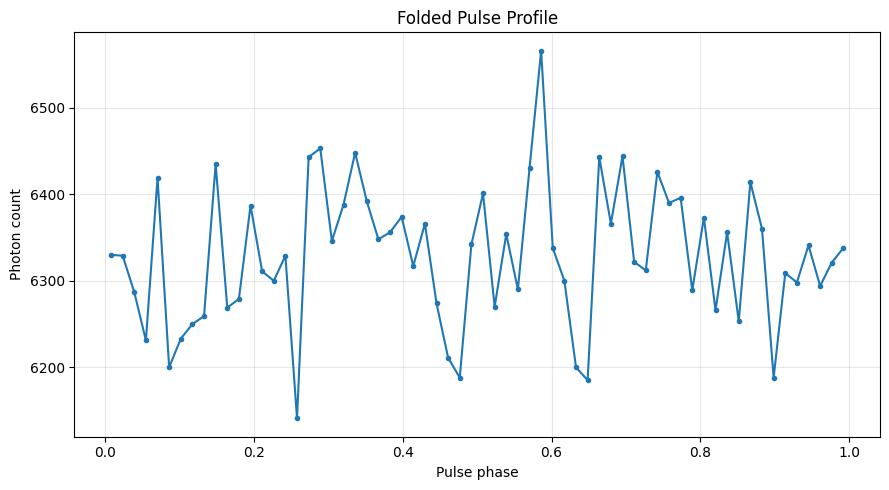

WindowsPath('C:/Users/vi/pulsar-clean/notebooks/images/05_folded_pulse_profile.png')

In [7]:
plt.figure(figsize=(9, 5))
plt.plot(pulse_profile["phase"], pulse_profile["photon_count"], marker="o", markersize=3)
plt.xlabel("Pulse phase")
plt.ylabel("Photon count")
plt.title("Folded Pulse Profile")
plt.grid(alpha=0.3)
plt.tight_layout()

plot_path = images_dir / "05_folded_pulse_profile.png"
plt.savefig(plot_path, dpi=150)

plt.show()

plot_path

In [8]:
profile_summary = pulse_profile["photon_count"].describe()

profile_summary

count      64.0000
mean     6329.1875
std        80.8243
min      6141.0000
25%      6277.7500
50%      6329.5000
75%      6387.2500
max      6566.0000
Name: photon_count, dtype: float64

## Summary

The folded pulse profile shows a non-uniform distribution of photon counts across phase bins. This supports the presence of a periodic signal in the photon arrival-time data.

The result also provides a simplified basis for the following XNAV demonstration, where phase shifts are interpreted as timing offsets.